In [556]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

# Load Data

In [557]:
# Load dataset
df = pd.read_csv('./data/raw/water_potability.csv')
# Ambil kolom yang dibutuhkan (Potability tetap diambil untuk acuan label kotor)
df_filtered = df[['ph', 'Solids', 'Turbidity', 'Potability']].dropna()
print(f'shape: {df.shape} --> setelah filter: {df_filtered.shape}')

shape: (3276, 10) --> setelah filter: (2785, 4)


# Menyuntikkan kolom Suhu pada dataset

In [558]:
# Simulasi suhu air toren di Indonesia (berkisar antara 24°C hingga 32°C)
# Kita tambahkan sedikit variasi acak (noise)
total_rows = len(df_filtered)
df_filtered['Temperature'] = np.random.uniform(24.0, 32.0, size=total_rows)
df_filtered.head()
df_filtered.shape

(2785, 5)

# Exploratory Data Analysis: Descriptive Analysis

## Melihat struktur dataset (tipe data, jumlah baris)

In [559]:
df_filtered.info()
print(f'Shape: {df_filtered.shape}')

<class 'pandas.core.frame.DataFrame'>
Index: 2785 entries, 1 to 3275
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ph           2785 non-null   float64
 1   Solids       2785 non-null   float64
 2   Turbidity    2785 non-null   float64
 3   Potability   2785 non-null   int64  
 4   Temperature  2785 non-null   float64
dtypes: float64(4), int64(1)
memory usage: 130.5 KB
Shape: (2785, 5)


## Melihat statistik deskriptif

In [560]:
df_filtered[['ph', 'Solids', 'Turbidity', 'Temperature']].describe()

,ph,Solids,Turbidity,Temperature
count,2785.000000,2785.000000,2785.000000,2785.000000
mean,7.080795,21971.018946,3.970230,27.974818
std,1.594320,8721.738165,0.784964,2.328235
min,0.000000,320.942611,1.450000,24.007122
25%,6.093092,15661.940335,3.440859,25.906012
50%,7.036752,20868.627979,3.958543,27.970053
75%,8.062066,27317.099444,4.515150,30.003724
max,14.000000,56867.859236,6.494749,31.997966


## Melihat Missing Values & Duplicates

In [561]:
print('\n--- Missing Values ---')
print(df_filtered.isnull().sum())
print('\n--- Duplicates ---')
print(df_filtered.duplicated().sum())


--- Missing Values ---
ph             0
Solids         0
Turbidity      0
Potability     0
Temperature    0
dtype: int64

--- Duplicates ---
0


# EDA: Univariate Analysis

## Membuat Box Plot & Membersihkan Outliers

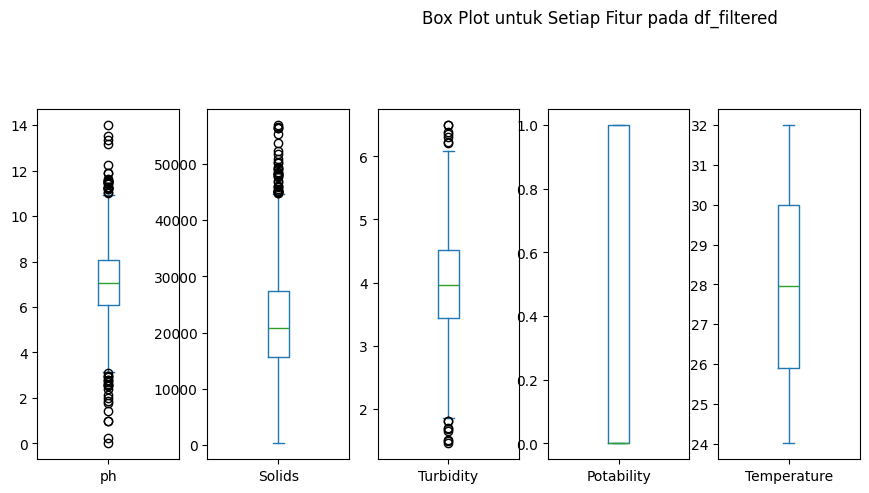

In [562]:
# Box Plot
df_filtered.plot(kind='box', subplots=True, layout=(2, 7), figsize=(15, 10), title='Box Plot untuk Setiap Fitur pada df_filtered')
plt.show()

In [563]:
def remove_extreme_outliers(dataframe):
    df_clean = dataframe.copy()
    
    # 1. Pembersihan Kolom pH (Batas Dua Arah)
    # Menggunakan pengali 3.0 (Ekstrem) agar fluktuasi asam/basa yang alami tetap aman
    Q1_ph = df_clean['ph'].quantile(0.25)
    Q3_ph = df_clean['ph'].quantile(0.75)
    IQR_ph = Q3_ph - Q1_ph
    
    batas_bawah_ph = Q1_ph - 3.0 * IQR_ph
    batas_atas_ph = Q3_ph + 3.0 * IQR_ph
    
    # Filter pH (Serta pastikan secara fisik tidak keluar dari rentang standar 0-14)
    df_clean = df_clean[
        (df_clean['ph'] >= max(0, batas_bawah_ph)) & 
        (df_clean['ph'] <= min(14, batas_atas_ph))
    ]
    
    # 2. Pembersihan Kolom Solids & Turbidity (Fokus Longgar pada Batas Atas)
    # Kita ingin mempertahankan air sekotor mungkin, jadi batas atas dinaikkan sangat tinggi (3.0 * IQR)
    for col in ['Solids', 'Turbidity']:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        
        batas_atas_ekstrem = Q3 + 3.0 * IQR
        
        # Filter: Buang nilai minus/nol yang mustahil secara fisik, 
        # dan buang yang di atas batas ekstrem saja
        df_clean = df_clean[
            (df_clean[col] > 0) & 
            (df_clean[col] <= batas_atas_ekstrem)
        ]
        
    return df_clean

# Eksekusi fungsi baru
df_filtered_clean = remove_extreme_outliers(df_filtered)

print(f"Jumlah baris awal: {len(df_filtered)}")
print(f"Jumlah baris setelah membuang outlier ekstrem: {len(df_filtered_clean)}")
print(f"Data yang berhasil diselamatkan: {len(df_filtered_clean) - 2400 if 'tergantung_hasil' else 'Banyak data kotor natural tetap aman!'}")

Jumlah baris awal: 2785
Jumlah baris setelah membuang outlier ekstrem: 2783
Data yang berhasil diselamatkan: 383


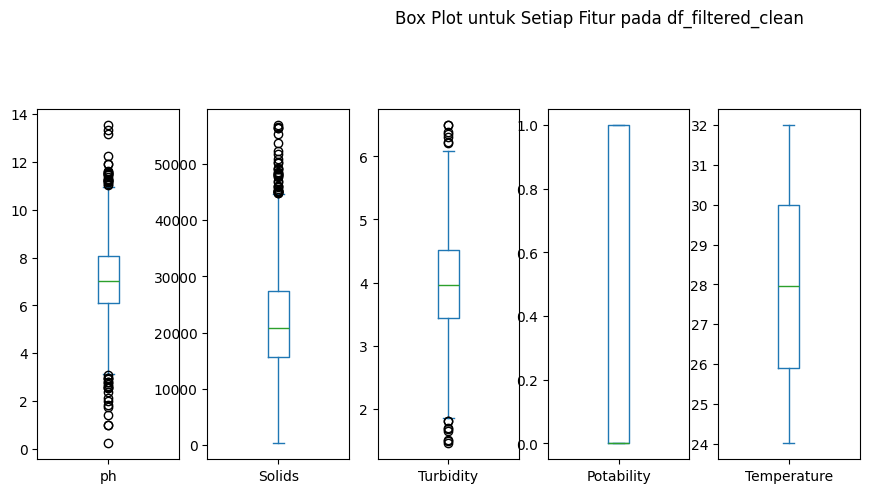

In [564]:
df_filtered_clean.plot(kind='box', subplots=True, layout=(2, 7), figsize=(15, 10), title='Box Plot untuk Setiap Fitur pada df_filtered_clean')
plt.show()

### Pembuatan Time-series Dataframe untuk Training model

In [565]:
# Pisahkan data air bersih dan kotor
df_bersih = df_filtered_clean[df_filtered_clean['Potability'] == 1].copy()
df_kotor = df_filtered_clean[df_filtered_clean['Potability'] == 0].copy()

# Parameter Simulasi Siklus
TOTAL_HARI_SIKLUS = 90
HARI_BERSIH = 75  # 75 hari pertama air sangat stabil (bersih)
HARI_KOTOR = 15   # 15 hari terakhir kualitas mulai turun menuju batas toleransi
JUMLAH_SIKLUS = 100 # Misalnya kita mau buat data dari 100 kali toren dikuras

# List untuk menampung semua siklus buatan
semua_siklus = []

In [566]:
# Buat perulangan untuk Siklus Penurunan Kualitas Air
for siklus_ke in range(1, JUMLAH_SIKLUS + 1):
    
    # Susun data agar semakin lama semakin kotor
    # Trik: Ambil sampel acak harian, lalu diurutkan nilainya dari yang paling kecil 
    # (paling bersih) ke paling besar (paling kotor) agar ada tren degradasi/penurunan
    # Tambahkan replace=True agar Pandas boleh mengambil ulang baris yang sama
    sampel_bersih = df_bersih.sample(n=HARI_BERSIH, replace=True).sort_values(by=['Turbidity', 'Solids'])
    sampel_kotor = df_kotor.sample(n=HARI_KOTOR, replace=True).sort_values(by=['Turbidity', 'Solids'])
    
    # Gabungkan data bersih dan kotor menjadi 1 rentang waktu (90 hari)
    data_1_siklus = pd.concat([sampel_bersih, sampel_kotor]).reset_index(drop=True)
    
    # Tambahkan ID Siklus (Sangat penting untuk LSTM/XGBoost)
    # Agar model tahu kapan 1 time-series toren selesai dan mulai toren baru
    data_1_siklus['Cycle_ID'] = siklus_ke
    
    # Langkah 4: Buat kolom target RUL (Remaining Useful Life)
    # Menghasilkan angka menurun dari 13 ke 0
    data_1_siklus['RUL'] = range(TOTAL_HARI_SIKLUS - 1, -1, -1)
    
    # Simpan siklus ke dalam list
    semua_siklus.append(data_1_siklus)

In [567]:
# Gabungkan semua list siklus menjadi satu DataFrame utuh siap training
df_timeseries = pd.concat(semua_siklus).reset_index(drop=True)

# (Opsional) Susun ulang urutan kolom agar lebih enak dibaca
df_timeseries = df_timeseries[['Cycle_ID', 'ph', 'Solids', 'Turbidity', 'Temperature', 'Potability', 'RUL']]
print(df_timeseries.head(10))
print(f'Shape dataset timeseries: {df_timeseries.shape}')
print(df_timeseries.dtypes)

   Cycle_ID        ph        Solids  Turbidity  Temperature  Potability  RUL
0         1  5.564342  11245.735767   2.285988    24.529435           1   89
1         1  9.900815  16233.134679   2.395002    24.977088           1   88
2         1  6.283104  26188.162174   2.663921    30.534823           1   87
3         1  7.899452  15896.365937   2.853767    31.672885           1   86
4         1  5.433466  31421.731633   2.871196    29.709470           1   85
5         1  6.382315  24259.751669   2.881370    30.745136           1   84
6         1  4.993531  13900.779271   3.153809    27.931992           1   83
7         1  7.968526  27008.011874   3.173879    30.568128           1   82
8         1  9.494243  21879.704208   3.189026    31.558896           1   81
9         1  8.053044  37086.546054   3.301575    25.022979           1   80
Shape dataset timeseries: (9000, 7)
Cycle_ID         int64
ph             float64
Solids         float64
Turbidity      float64
Temperature    float64
Po

### Selingan: untuk make sure berapa jumlah siklus yang pas untuk training model

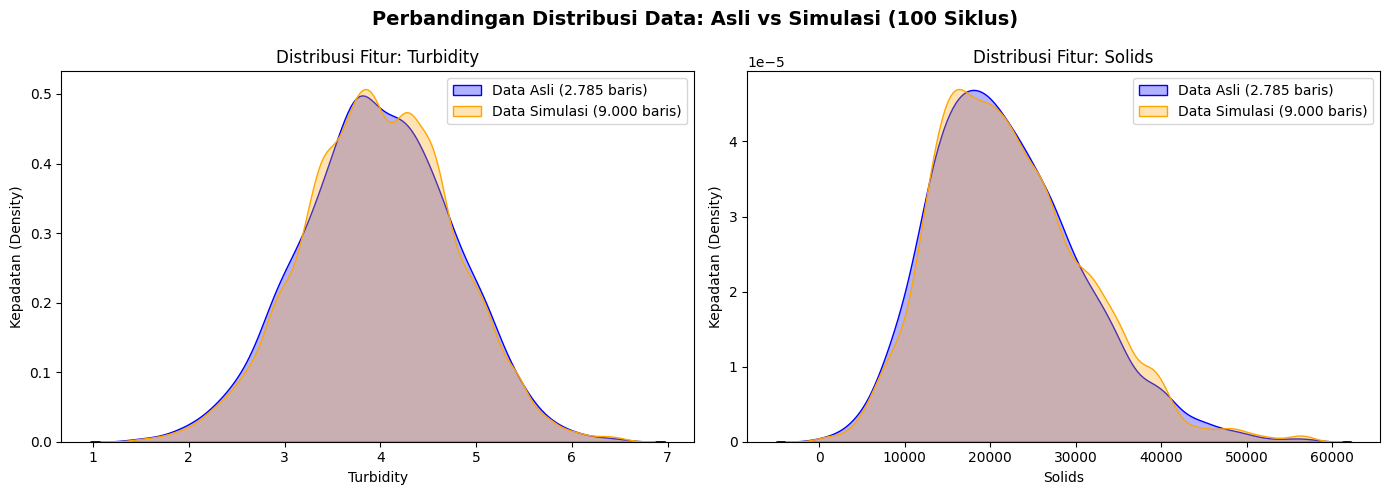

In [568]:
# Agar dapat mengetahui berapa siklus yang pas untuk training, kita bisa cek distribusi data asli vs simulasi

import matplotlib.pyplot as plt
import seaborn as sns

# Pastikan df_filtered (data asli) dan df_timeseries (data simulasi 100 siklus) sudah ada di memori

# Memilih fitur yang ingin dicek (misalnya Turbidity dan Solids)
fitur_yang_dicek = ['Turbidity', 'Solids']

# Membuat figure dan axis untuk plot berdampingan
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Perbandingan Distribusi Data: Asli vs Simulasi (100 Siklus)', fontsize=14, fontweight='bold')

for i, fitur in enumerate(fitur_yang_dicek):
    # Plot distribusi data asli (Warna Biru)
    sns.kdeplot(data=df_filtered, x=fitur, ax=axes[i], color='blue', label='Data Asli (2.785 baris)', fill=True, alpha=0.3)
    
    # Plot distribusi data simulasi (Warna Oranye)
    sns.kdeplot(data=df_timeseries, x=fitur, ax=axes[i], color='orange', label='Data Simulasi (9.000 baris)', fill=True, alpha=0.3)
    
    axes[i].set_title(f'Distribusi Fitur: {fitur}')
    axes[i].set_xlabel(fitur)
    axes[i].set_ylabel('Kepadatan (Density)')
    axes[i].legend()

# Merapikan jarak antar plot dan menampilkannya
plt.tight_layout()
plt.show()

## Melihat Distribution Plot untuk melihat skewness data 

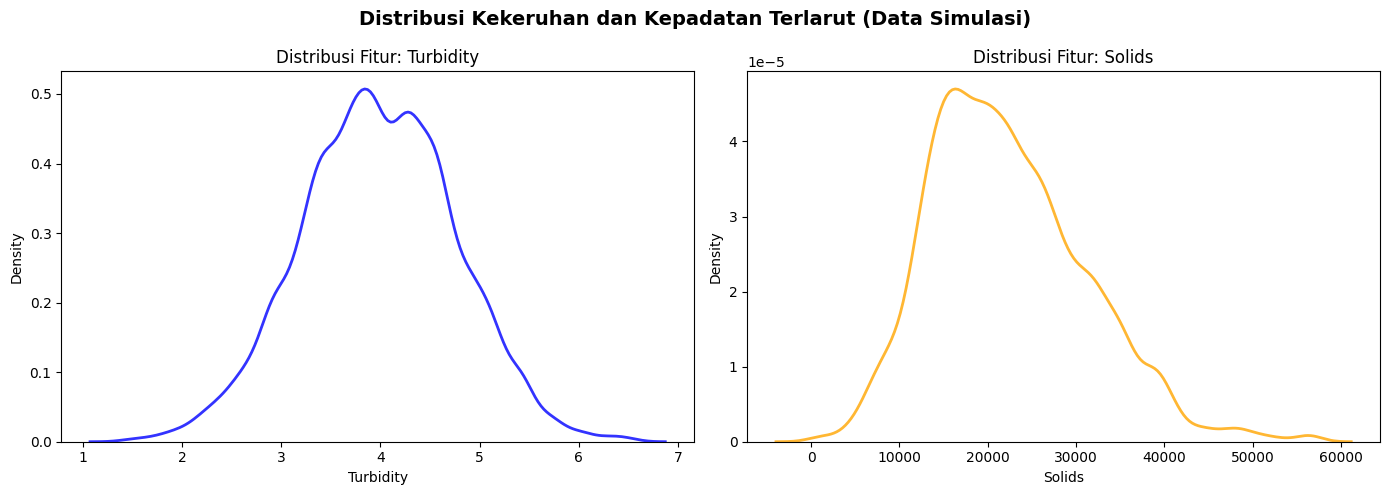

In [569]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribusi Kekeruhan dan Kepadatan Terlarut (Data Simulasi)', fontsize=14, fontweight='bold')

# Menggunakan fill=False untuk menghindari error ValueError NumPy sebelumnya
sns.kdeplot(data=df_timeseries, x='Turbidity', ax=axes[0], color='blue', fill=False, alpha=0.8, linewidth=2)
axes[0].set_title('Distribusi Fitur: Turbidity')
axes[0].set_xlabel('Turbidity')

sns.kdeplot(data=df_timeseries, x='Solids', ax=axes[1], color='orange', fill=False, alpha=0.8, linewidth=2)
axes[1].set_title('Distribusi Fitur: Solids')
axes[1].set_xlabel('Solids')

plt.tight_layout()
plt.show()

# Feature Engineering

In [575]:
# Pastikan data urut berdasarkan waktu sebelum dihitung
df_timeseries = df_timeseries.sort_values(by=['Cycle_ID', 'RUL'], ascending=[True, False])

# 1. Rolling Averages (Rata-rata bergerak 3 hari terakhir)
# Harus menggunakan groupby('Cycle_ID') agar perhitungan tidak melompat antar siklus yang berbeda
df_timeseries['Turbidity_MA_3'] = df_timeseries.groupby('Cycle_ID')['Turbidity'].transform(lambda x: x.rolling(window=3, min_periods=1).mean())
df_timeseries['Solids_MA_3'] = df_timeseries.groupby('Cycle_ID')['Solids'].transform(lambda x: x.rolling(window=3, min_periods=1).mean())
df_timeseries['ph_MA_3'] = df_timeseries.groupby('Cycle_ID')['ph'].transform(lambda x: x.rolling(window=3, min_periods=1).mean())

# 2. Rate of Change (Kecepatan perubahan dari 1 hari sebelumnya / selisih harian)
# Menggunakan diff() untuk mencari selisih. fillna(0) digunakan untuk hari pertama di setiap siklus
df_timeseries['Turbidity_Diff'] = df_timeseries.groupby('Cycle_ID')['Turbidity'].diff().fillna(0)
df_timeseries['Solids_Diff'] = df_timeseries.groupby('Cycle_ID')['Solids'].diff().fillna(0)
df_timeseries['ph_Diff'] = df_timeseries.groupby('Cycle_ID')['ph'].diff().fillna(0)

# 3. Volatilitas (Standard Deviation - 3 Hari)
df_timeseries['Turbidity_Std_3'] = df_timeseries.groupby('Cycle_ID')['Turbidity'].transform(lambda x: x.rolling(window=3, min_periods=1).std().fillna(0))
df_timeseries['Solids_Std_3'] = df_timeseries.groupby('Cycle_ID')['Solids'].transform(lambda x: x.rolling(window=3, min_periods=1).std().fillna(0))

print("Fitur/kolom baru berhasil ditambahkan!")
print(df_timeseries[['Cycle_ID', 'RUL', 'Turbidity', 'Turbidity_MA_3', 'Turbidity_Diff', 'Turbidity_Std_3', 'Solids', 'Solids_MA_3', 'Solids_Diff', 'Solids_Std_3', 'ph', 'ph_MA_3', 'ph_Diff']].head())

Fitur/kolom baru berhasil ditambahkan!
   Cycle_ID  RUL  Turbidity  Turbidity_MA_3  Turbidity_Diff  Turbidity_Std_3  \
0         1   89   0.165731        0.165731        0.000000         0.000000   
1         1   88   0.187342        0.176537        0.021612         0.015282   
2         1   87   0.240654        0.197909        0.053312         0.038563   
3         1   86   0.278291        0.235429        0.037636         0.045699   
4         1   85   0.281746        0.266897        0.003455         0.022792   

     Solids  Solids_MA_3  Solids_Diff  Solids_Std_3        ph   ph_MA_3  \
0  0.193199     0.193199     0.000000      0.000000  0.400852  0.400852   
1  0.281398     0.237298     0.088199      0.062366  0.726566  0.563709   
2  0.457447     0.310681     0.176049      0.134536  0.454839  0.527419   
3  0.275442     0.338096    -0.182005      0.103404  0.576243  0.585883   
4  0.550000     0.427630     0.274557      0.139686  0.391022  0.474035   

    ph_Diff  
0  0.000000  
1

# Data Scaling & Normalization

In [580]:
import pickle
import os

In [586]:
# Memastikan folder 'models' tersedia untuk menyimpan file scaler.pkl
os.makedirs('modelsz', exist_ok=True)

In [587]:
# 1. Tentukan kolom fitur (X) yang akan dinormalisasi
# PENTING: Jangan masukkan 'Cycle_ID', 'RUL', atau 'Potability' (jika masih ada)
fitur_x = [
    'ph', 'Solids', 'Turbidity', 'Temperature',
    'Turbidity_MA_3', 'Solids_MA_3', 'ph_MA_3',
    'Turbidity_Diff', 'Solids_Diff', 'ph_Diff',
    'Turbidity_Std_3', 'Solids_Std_3'
]

In [588]:
# 2. Inisialisasi MinMaxScaler
scaler = MinMaxScaler()

In [589]:
# 3. Fit dan Transform data (Menghitung batas Min-Max dan mengubah skala menjadi 0-1)
# Kita membuat salinan dataframe agar data asli tidak tertimpa jika terjadi error
df_scaled = df_timeseries.copy()
df_scaled[fitur_x] = scaler.fit_transform(df_scaled[fitur_x])

In [590]:
# 4. Simpan objek scaler ke dalam file .pkl untuk digunakan di backend FastAPI nanti
with open('models/scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)

In [591]:
# 5. Cek hasil akhir
print("\nCuplikan 5 baris pertama data yang sudah dinormalisasi (Rentang 0.0 - 1.0):")
print(df_scaled[['Cycle_ID', 'RUL'] + fitur_x].head())


Cuplikan 5 baris pertama data yang sudah dinormalisasi (Rentang 0.0 - 1.0):
   Cycle_ID  RUL        ph    Solids  Turbidity  Temperature  Turbidity_MA_3  \
0         1   89  0.400852  0.193199   0.165731     0.065364        0.171697   
1         1   88  0.726566  0.281398   0.187342     0.121385        0.183487   
2         1   87  0.454839  0.457447   0.240654     0.816898        0.206806   
3         1   86  0.576243  0.275442   0.278291     0.959318        0.247743   
4         1   85  0.391022  0.550000   0.281746     0.713610        0.282077   

   Solids_MA_3   ph_MA_3  Turbidity_Diff  Solids_Diff   ph_Diff  \
0     0.174642  0.258980        0.797598     0.501082  0.497441   
1     0.230023  0.539018        0.815497     0.552278  0.738908   
2     0.322177  0.476616        0.841752     0.603270  0.295997   
3     0.356604  0.577146        0.828769     0.395437  0.587444   
4     0.469041  0.384819        0.800459     0.660450  0.360129   

   Turbidity_Std_3  Solids_Std_3  
0   

In [595]:
df_scaled.to_csv('data/processed/simulated_toren_data_scaled.csv', index=False)